In [15]:
import numpy as np
import matplotlib.pyplot as plt
def f(x):
    return (np.abs(np.sin(x)) + 0.5 * np.cos(2*x) + 0.25 * np.sin(3*x))*10

x_values = np.linspace(1,10,100)
y_values = f(x_values)

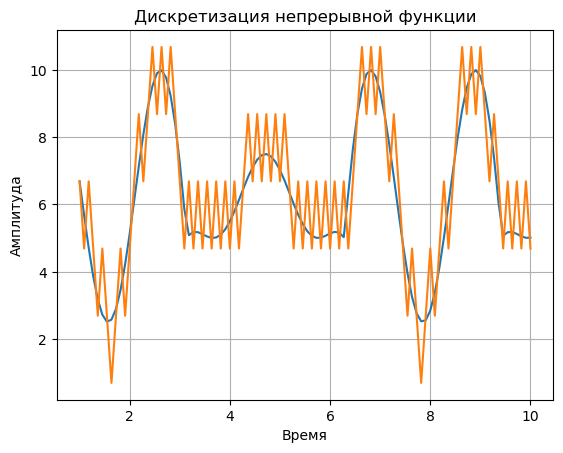

In [16]:
y_disret = [y_values[0]]
for i in range(1,len(y_values)):
    y_disret.append(y_disret[-1]+int(np.sign(y_values[i]-y_disret[-1]))*2)

plt.plot(x_values, y_values)
plt.plot(x_values, y_disret)
plt.title('Дискретизация непрерывной функции')
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.grid()


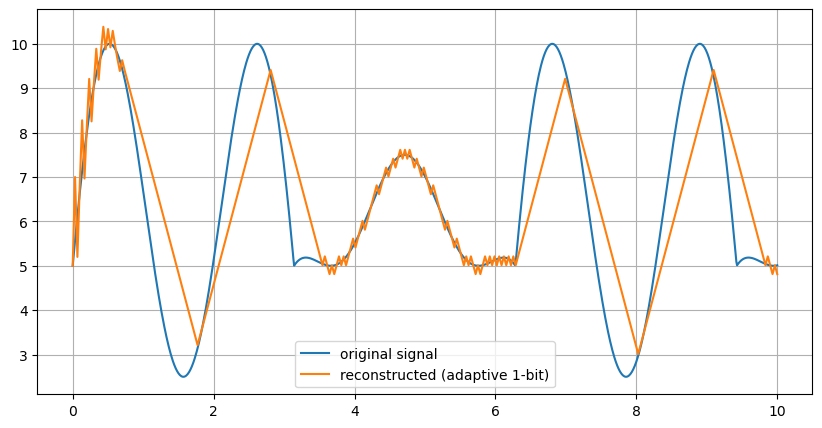

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (np.abs(np.sin(x)) +
            0.5*np.cos(2*x) +
            0.25*np.sin(3*x)) * 10

x_ = np.linspace(0, 10, 1000)
x = np.linspace(0, 10, 300)

y_ = f(x_)
y = f(x)

theta = 1.0
alpha = 0.5
M_min = 0.2
N = len(y)

y_hat = np.zeros(N)
c = np.zeros(N)
p = np.zeros(N)
M = np.zeros(N)

y_hat[0] = y[0]
M[0] = 2.0
p[0] = 0.0

for i in range(1, N):
    c[i] = np.sign(y[i] - y_hat[i - 1])
    y_hat[i] = y_hat[i - 1] + M[i - 1] * c[i]

    p[i] = alpha * p[i - 1] + (1 - alpha) * abs(y[i] - y[i - 1])

    if i < N - 1:
        if p[i] > theta:
            M[i] = max(1.1 * M[i - 1], M_min)
        else:
            M[i] = max(0.9 * M[i - 1], M_min)

plt.figure(figsize=(10, 5))
plt.plot(x_, y_, label="original signal")
plt.plot(x, y_hat, label="reconstructed (adaptive 1-bit)")
plt.legend()
plt.grid()
plt.show()

# Многомерная реализация с использованием обхода зигзага


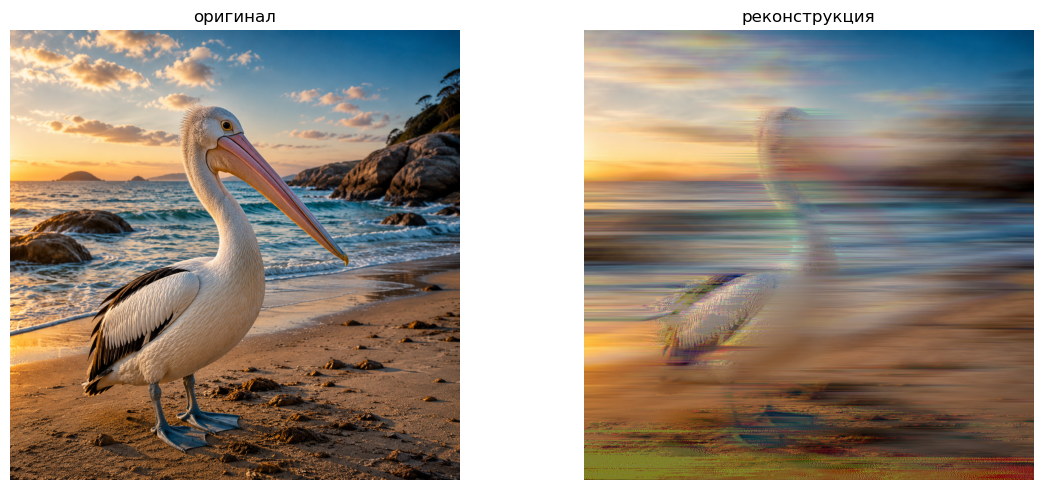

PSNR: 15.51 dB


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def adaptive_1bit_2d(channel: np.ndarray,
                     theta=15.0,
                     alpha=0.5,
                     M_min=0.5,
                     M_init=8.0) -> np.ndarray:
    """
    channel: 2D массив float [0..255], shape (H, W)
    возвращает восстановленный канал той же формы
    """
    H, W = channel.shape
    y_hat = np.zeros((H, W))
    M     = np.zeros((H, W))
    p     = np.zeros((H, W))

    for row in range(H):
        cols = range(W) if row % 2 == 0 else range(W - 1, -1, -1)
        cols = list(cols)

        for k, col in enumerate(cols):
            if row == 0 and k == 0:
                y_hat[row, col] = channel[row, col]
                M[row, col]     = M_init
                p[row, col]     = 0.0
                continue

            if k > 0:
                pr, pc = row, cols[k - 1]
            else:
                pr, pc = row - 1, cols[0]

            y_prev     = channel[pr, pc]
            yhat_prev  = y_hat[pr, pc]
            M_prev     = M[pr, pc]
            p_prev     = p[pr, pc]

            c = np.sign(channel[row, col] - yhat_prev)
            if c == 0:
                c = 1

            y_hat[row, col] = yhat_prev + M_prev * c

            p[row, col] = alpha * p_prev + (1 - alpha) * abs(channel[row, col] - y_prev)

            if p[row, col] > theta:
                M[row, col] = max(1.1 * M_prev, M_min)
            else:
                M[row, col] = max(0.9 * M_prev, M_min)

    return np.clip(y_hat, 0, 255)


def process_image(img_array: np.ndarray, **kwargs) -> np.ndarray:
    """img_array: H×W×3, uint8"""
    img_f = img_array.astype(float)
    result = np.zeros_like(img_f)
    for c in range(3):
        result[:, :, c] = adaptive_1bit_2d(img_f[:, :, c], **kwargs)
    return result.astype(np.uint8)


img = np.array(Image.open("image.png").convert("RGB"))
reconstructed = process_image(img, theta=15.0, alpha=0.5, M_min=0.5, M_init=8.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img);           axes[0].set_title("оригинал");       axes[0].axis("off")
axes[1].imshow(reconstructed); axes[1].set_title("реконструкция");  axes[1].axis("off")
plt.tight_layout()
plt.show()

# метрика качества (PSNR)
mse = np.mean((img.astype(float) - reconstructed.astype(float)) ** 2)
psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
print(f"PSNR: {psnr:.2f} dB")

# Многомерная реализация адаптивного метода с переходом по строкам

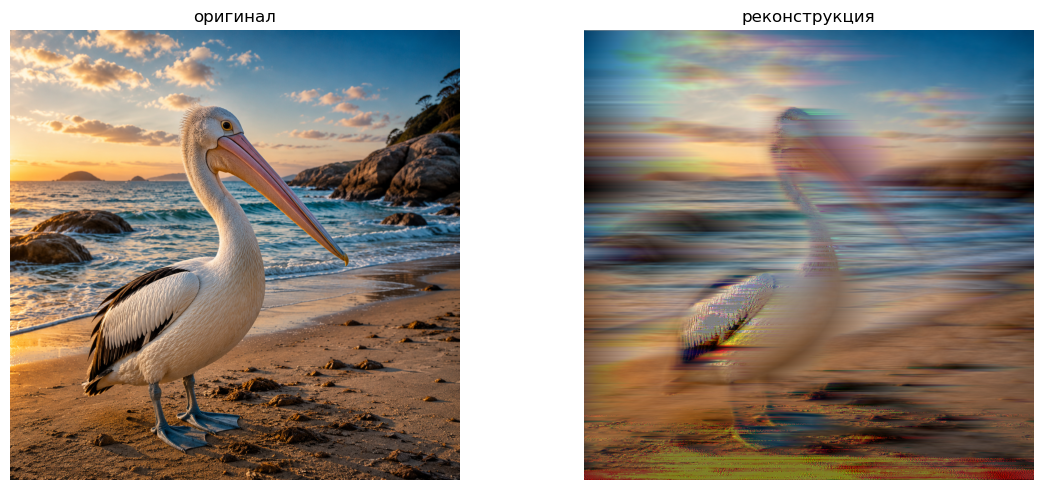

PSNR: 14.22 dB


In [35]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def adaptive_1bit_2d(channel: np.ndarray,
                     theta=15.0,
                     alpha=0.5,
                     M_min=0.5,
                     M_init=8.0) -> np.ndarray:
    H, W = channel.shape
    y_hat = np.zeros((H, W))
    M     = np.zeros((H, W))
    p     = np.zeros((H, W))

    # инициализация первого пикселя
    y_hat[0, 0] = channel[0, 0]
    M[0, 0]     = M_init
    p[0, 0]     = 0.0

    # все пиксели в порядке строк слева направо
    for row in range(H):
        for col in range(W):
            if row == 0 and col == 0:
                continue

            # предыдущий пиксель вдоль пути обхода
            if col > 0:
                pr, pc = row, col - 1
            else:
                pr, pc = row - 1, W - 1

            y_prev    = channel[pr, pc]
            yhat_prev = y_hat[pr, pc]
            M_prev    = M[pr, pc]
            p_prev    = p[pr, pc]

            c = np.sign(channel[row, col] - yhat_prev)
            if c == 0:
                c = 1

            y_hat[row, col] = yhat_prev + M_prev * c

            p[row, col] = alpha * p_prev + (1 - alpha) * abs(channel[row, col] - y_prev)

            if p[row, col] > theta:
                M[row, col] = max(1.1 * M_prev, M_min)
            else:
                M[row, col] = max(0.9 * M_prev, M_min)

    return np.clip(y_hat, 0, 255)


def process_image(img_array: np.ndarray, **kwargs) -> np.ndarray:
    img_f  = img_array.astype(float)
    result = np.zeros_like(img_f)
    for c in range(3):
        result[:, :, c] = adaptive_1bit_2d(img_f[:, :, c], **kwargs)
    return result.astype(np.uint8)


img = np.array(Image.open("image.png").convert("RGB"))
reconstructed = process_image(img, theta=15.0, alpha=0.5, M_min=0.5, M_init=8.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img);           axes[0].set_title("оригинал");      axes[0].axis("off")
axes[1].imshow(reconstructed); axes[1].set_title("реконструкция"); axes[1].axis("off")
plt.tight_layout()
plt.show()

mse  = np.mean((img.astype(float) - reconstructed.astype(float)) ** 2)
psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
print(f"PSNR: {psnr:.2f} dB")

# Многомерная реализация адаптивного метода с контролем шага дискретизации

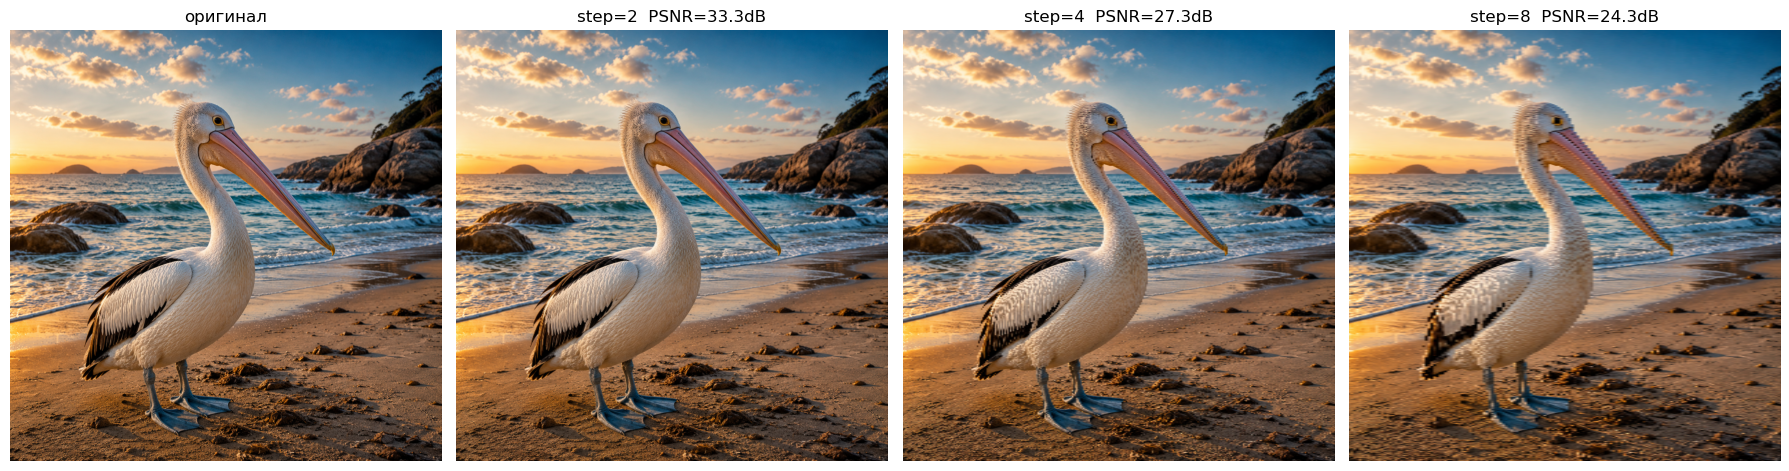

In [38]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def reconstruct_1bit_2d(channel: np.ndarray, step: int = 1) -> np.ndarray:
    """
    step — шаг дискретизации в пикселях (1 = каждый пиксель, 2 = каждый второй, ...)
    между отсчётами — линейная интерполяция вдоль строки
    """
    H, W = channel.shape
    y_hat = np.zeros((H, W))

    for row in range(H):
        # индексы отсчётов в строке
        sample_cols = list(range(0, W, step))
        if sample_cols[-1] != W - 1:
            sample_cols.append(W - 1)

        # 1-bit DPCM только на отсчётах
        y_hat[row, sample_cols[0]] = channel[row, sample_cols[0]]

        for k in range(1, len(sample_cols)):
            col      = sample_cols[k]
            prev_col = sample_cols[k - 1]

            c = np.sign(channel[row, col] - y_hat[row, prev_col])
            if c == 0:
                c = 1

            y_hat[row, col] = y_hat[row, prev_col] + c * abs(
                channel[row, col] - channel[row, prev_col]
            )

            # линейная интерполяция между отсчётами
            if col - prev_col > 1:
                for interp_col in range(prev_col + 1, col):
                    t = (interp_col - prev_col) / (col - prev_col)
                    y_hat[row, interp_col] = (
                        (1 - t) * y_hat[row, prev_col] +
                        t       * y_hat[row, col]
                    )

    return np.clip(y_hat, 0, 255)


def process_image(img_array: np.ndarray, step: int = 1) -> np.ndarray:
    img_f  = img_array.astype(float)
    result = np.zeros_like(img_f)
    for c in range(3):
        result[:, :, c] = reconstruct_1bit_2d(img_f[:, :, c], step=step)
    return result.astype(np.uint8)


# --- пример использования ---
img = np.array(Image.open("image.png").convert("RGB"))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img); axes[0].set_title("оригинал"); axes[0].axis("off")

for ax, step in zip(axes[1:], [2, 4, 8]):
    rec = process_image(img, step=step)
    mse  = np.mean((img.astype(float) - rec.astype(float)) ** 2)
    psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
    ax.imshow(rec)
    ax.set_title(f"step={step}  PSNR={psnr:.1f}dB")
    ax.axis("off")

plt.tight_layout()
plt.show()

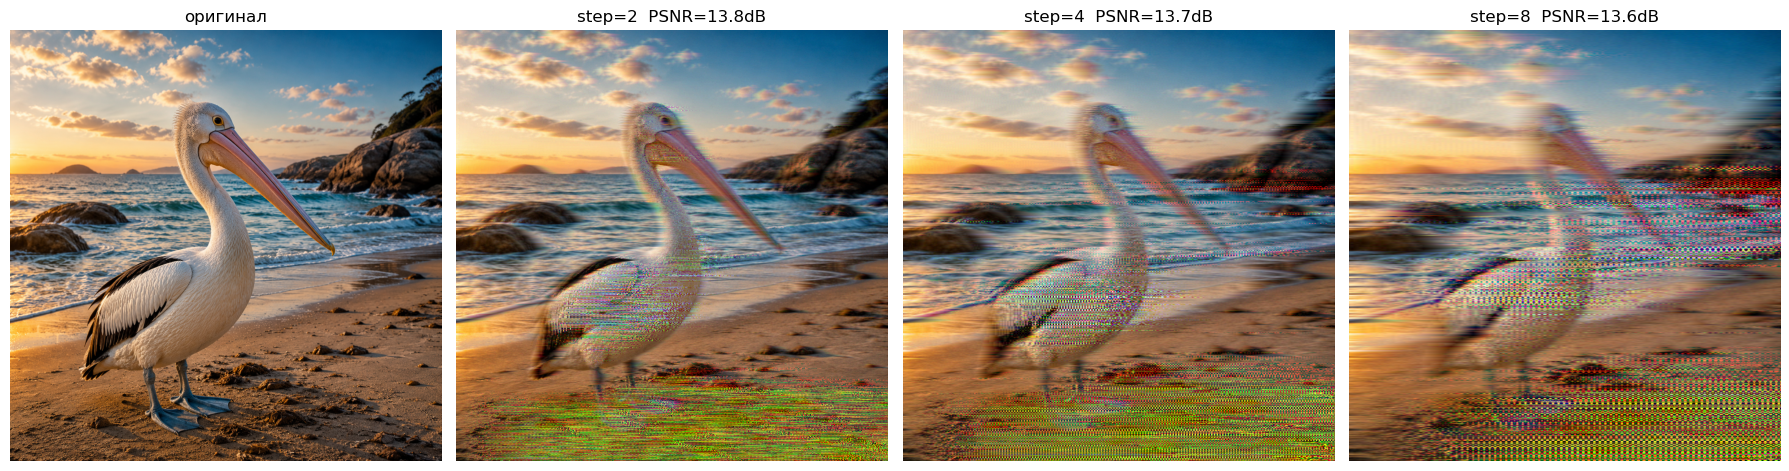

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def adaptive_1bit_2d(channel: np.ndarray,
                     step:   int   = 1,
                     theta:  float = 15.0,
                     alpha:  float = 0.5,
                     M_min:  float = 0.5,
                     M_init: float = 8.0) -> np.ndarray:
    H, W = channel.shape
    y_hat = np.zeros((H, W))
    M     = np.zeros((H, W))
    p     = np.zeros((H, W))

    # индексы отсчётов по столбцам
    sample_cols = list(range(0, W, step))
    if sample_cols[-1] != W - 1:
        sample_cols.append(W - 1)

    for row in range(H):
        y_hat[row, sample_cols[0]] = channel[row, sample_cols[0]]
        M[row, sample_cols[0]]     = M_init
        p[row, sample_cols[0]]     = 0.0

        for k in range(1, len(sample_cols)):
            col      = sample_cols[k]
            prev_col = sample_cols[k - 1]

            y_prev    = channel[row, prev_col]
            yhat_prev = y_hat[row, prev_col]
            M_prev    = M[row, prev_col]
            p_prev    = p[row, prev_col]

            # 1-bit + адаптивная амплитуда
            c = np.sign(channel[row, col] - yhat_prev)
            if c == 0:
                c = 1

            y_hat[row, col] = yhat_prev + M_prev * c

            p[row, col] = alpha * p_prev + (1 - alpha) * abs(channel[row, col] - y_prev)

            if p[row, col] > theta:
                M[row, col] = max(1.1 * M_prev, M_min)
            else:
                M[row, col] = max(0.9 * M_prev, M_min)

            # линейная интерполяция между отсчётами
            for interp_col in range(prev_col + 1, col):
                t = (interp_col - prev_col) / (col - prev_col)
                y_hat[row, interp_col] = (
                    (1 - t) * y_hat[row, prev_col] +
                      t     * y_hat[row, col]
                )

    return np.clip(y_hat, 0, 255)


def process_image(img_array: np.ndarray, **kwargs) -> np.ndarray:
    img_f  = img_array.astype(float)
    result = np.zeros_like(img_f)
    for c in range(3):
        result[:, :, c] = adaptive_1bit_2d(img_f[:, :, c], **kwargs)
    return result.astype(np.uint8)


img = np.array(Image.open("image.png").convert("RGB"))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img); axes[0].set_title("оригинал"); axes[0].axis("off")

for ax, step in zip(axes[1:], [1, 4, 8]):
    rec = process_image(img, step=step, theta=15.0, alpha=0.5, M_min=5, M_init=8.0)
    mse  = np.mean((img.astype(float) - rec.astype(float)) ** 2)
    psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
    ax.imshow(rec)
    ax.set_title(f"step={step}  PSNR={psnr:.1f}dB")
    ax.axis("off")

plt.tight_layout()
plt.show()